# Projekt: Auswirkungen von Wetterereignissen auf die urbane Mobilität
### Team: Aron Milojevic, Mateusz Pacyga und Ajya Pal.

## 1. Einleitung & Story
In diesem Projekt analysieren wir, wie extremes Wetter (Regen, Schnee) das Buchungsverhalten von Taxis in New York City beeinflusst. 
Wir nutzen dafür Millionen von Datensätzen der NYC TLC und historische Wetterdaten der NOAA.

## 2. Big Data Kriterien (Theoretische Betrachtung)

Gemäß der Projektspezifikation analysieren wir unser Vorhaben anhand der 5 Vs und der 4 Ebenen der Datenverarbeitung.

### Die 5 Vs unseres Projekts
* **Volume:** Wir arbeiten mit dem NYC TLC Datensatz, der Millionen von einzelnen Fahrten enthält und somit ein hohes Datenvolumen aufweist.
* **Velocity:** In der realen Welt entstehen Taxi-Buchungsdaten kontinuierlich im Sekundentakt (Real-time).
* **Variety:** Wir kombinieren zwei unterschiedliche Datentypen: Semistrukturierte Fahrtdaten (JSON/CSV) und strukturierte Wetterdaten (NOAA).
* **Veracity:** Die Datenqualität muss bereinigt werden (Data Cleaning), um Ausreißer wie unmögliche Fahrpreise oder Zeitstempel zu entfernen.
* **Value:** Die Verknüpfung zeigt den wirtschaftlichen Wert auf, indem sie Vorhersagen über die Nachfrage bei Schlechtwetter ermöglicht.

### Die 4 Ebenen der Datenverarbeitung
1. **Data Source:** Nutzung von Open Data Quellen (Kaggle/NYC Open Data & NOAA).
2. **Data Storage:** Speicherung der Rohdaten in einer MongoDB (NoSQL), um flexibel auf Attribute zuzugreifen.
3. **Data Analysis:** Durchführung einer MapReduce-Berechnung zur Aggregation der Fahrten pro Stunde bei Regen/Sonne.
4. **Data Output:** Visualisierung der Ergebnisse in Form von Diagrammen direkt in diesem Jupyter Notebook.

## 3. Infrastruktur & Architektur

Um die Multiuser-Fähigkeit und eine konsistente Arbeitsumgebung zu garantieren, nutzen wir folgende Infrastruktur:

* **Docker:** Kapselung der Dienste in Containern, damit alle Teammitglieder (Aron, Mateusz, Ajay) die identische Umgebung nutzen.
* **MongoDB:** Als NoSQL-Datenbank für die flexible Speicherung der Taxi-Fahrten und Wetterdaten.
* **JupyterLab:** Zentrale Plattform für die Datenanalyse, Dokumentation und Code-Ausführung.
* **Git/GitHub:** Versionskontrolle und gemeinsames Filesharing des Codes zur Ermöglichung einer parallelen Zusammenarbeit.

### Architektur-Diagramm
Das System besteht aus zwei Haupt-Containern (Jupyter und MongoDB), die über ein internes Docker-Netzwerk miteinander kommunizieren. Die Daten werden von lokalen CSV- und Parquet-Dateien eingelesen und in die NoSQL-überführt.Datenbank 

![Architektur](architektur.png)ter zeigt]

## 4. Implementierung und Datenimport

Nachdem die Infrastruktur mittels Docker bereitgestellt wurde, erfolgt nun die technische Umsetzung. In diesem Schritt installieren wir die notwendigen Schnittstellen und laden die Datensätze in unsere NoSQL-Datenbank.

### 4.1 Vorbereitung der Python-Umgebung
Wir installieren `pymongo` für die Datenbankkommunikation und `pyarrow`, um das speichereffiziente Parquet-Format der Taxi-Daten verarbeiten zu können.

In [1]:
!pip install pymongo pyarrow



### 4.2 Aufbau der Datenbankverbindung und ETL-Prozess
Der folgende Code stellt die Verbindung zum MongoDB-Container her und führt den Import der CSV- (Wetter) und Parquet-Dateien (Taxi) durch. Dabei werden die Daten in Dokumente umgewandelt und in Kollektionen gespeichert.

In [1]:
import pandas as pd
from pymongo import MongoClient

# 1. Verbindung zur MongoDB aufbauen 
client = MongoClient('mongodb://mongodb:27017/')
db = client['nyc_taxi_weather']

print("Verbindung zur MongoDB steht!")

# 2. Wetter-Daten einlesen und speichern
weather_file = 'New York, NY, United Stat... 2023-01-01 to 2023-01-31.csv'
weather_df = pd.read_csv(weather_file)

weather_collection = db['weather']
weather_collection.insert_many(weather_df.to_dict('records'))
print(f"Erfolg: {len(weather_df)} Wetter-Datensätze in MongoDB gespeichert!")

# 3. Taxi-Daten einlesen und speichern 
taxi_file = 'yellow_tripdata_2023-01.parquet'
taxi_df = pd.read_parquet(taxi_file)


taxi_sample = taxi_df.head(100000)

taxi_collection = db['trips']
taxi_collection.insert_many(taxi_sample.to_dict('records'))
print(f"Erfolg: {len(taxi_sample)} Taxi-Fahrten in MongoDB gespeichert!")


Verbindung zur MongoDB steht!
Erfolg: 744 Wetter-Datensätze in MongoDB gespeichert!
Erfolg: 100000 Taxi-Fahrten in MongoDB gespeichert!


### 4.3 Datenübersicht und Strukturprüfung

Um die Qualität und Struktur der Rohdaten sicherzustellen, führen wir eine kurze explorative Datenanalyse (EDA) durch. Dabei betrachten wir die ersten fünf Datensätze (Head-View) beider Quellen, um die Spaltennamen und das Format der geladenen Daten zu validieren.

* **NYC Taxi Daten:** Enthalten Informationen zu Fahrtzeiten, Start-/Zielorten und Fahrpreisen.
* **Wetterdaten:** Enthalten meteorologische Parameter wie Temperatur, Niederschlag und Windgeschwindigkeit.

Diese Vorschau bestätigt, dass die Dateien korrekt eingelesen wurden und für den anschließenden Transfer in die MongoDB bereitstehen.

In [2]:
import pandas as pd

# 1. Wetter-Daten anzeigen
taxi_df = pd.read_parquet('yellow_tripdata_2023-01.parquet')
print("--- Taxi-Daten (Erste 5 Zeilen) ---")
display(taxi_df.head(5))

# 2. Taxi-Daten anzeigen
weather_df = pd.read_csv('New York, NY, United Stat... 2023-01-01 to 2023-01-31.csv')
print("\n--- Wetter-Daten (Erste 5 Zeilen) ---")
display(weather_df.head(5))

--- Taxi-Daten (Erste 5 Zeilen) ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00



--- Wetter-Daten (Erste 5 Zeilen) ---


,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,preciptype,snow,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,"New York, NY, United States",2023-01-01T00:00:00,12.2,12.2,11.0,92.56,0.185,100,rain,0.0,...,1007.1,100.0,11.3,227,0.8,0,NaN,"Rain, Overcast",rain,"72505394728,KEWR,KLGA,72502014734,D2180,KNYC,7..."
1,"New York, NY, United States",2023-01-01T01:00:00,11.7,11.7,10.5,92.32,0.028,100,rain,0.0,...,1007.2,100.0,10.6,228,0.8,0,NaN,"Rain, Overcast",rain,"72505394728,KEWR,KLGA,72502014734,D2180,KNYC,7..."
2,"New York, NY, United States",2023-01-01T02:00:00,11.7,11.7,9.9,88.94,0.094,100,rain,0.0,...,1006.9,51.8,11.6,227,0.8,0,NaN,"Rain, Partially cloudy",rain,"72505394728,KEWR,KLGA,72502014734,D2180,KNYC,7..."
3,"New York, NY, United States",2023-01-01T03:00:00,11.1,11.1,9.6,90.38,0.000,0,NaN,0.0,...,1007.8,25.4,13.2,224,0.8,0,NaN,Partially cloudy,partly-cloudy-night,"72505394728,KEWR,KLGA,72502014734,D2180,KNYC,7..."
4,"New York, NY, United States",2023-01-01T04:00:00,11.4,11.4,9.0,85.38,0.000,0,NaN,0.0,...,1008.1,20.3,14.7,222,0.8,0,NaN,Partially cloudy,partly-cloudy-night,"72505394728,KEWR,KLGA,72502014734,D2180,KNYC,7..."


### 5. Datenanalyse mit MapReduce
Um die Anforderungen an eine Big-Data-Verarbeitung zu erfüllen, implementieren wir eine MapReduce-Aggregation. Wir transformieren die Daten (Map) und aggregieren sie anschließend (Reduce), um Erkenntnisse über die Taxinachfrage in Abhängigkeit vom Wetter zu gewinnen.

In [6]:
# 1. Spalten in Datetime umwandeln
taxi_df['tpep_pickup_datetime'] = pd.to_datetime(taxi_df['tpep_pickup_datetime'])
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])

# 2. Runden auf die volle Stunde 
taxi_df['date_hour'] = taxi_df['tpep_pickup_datetime'].dt.floor('h')
weather_df['date_hour'] = weather_df['datetime'].dt.floor('h')

# 3. Mergen auf gemeinsamen Spalte
analysis_df = taxi_df.merge(
    weather_df, 
    on='date_hour', 
    how='left'
)

# Ergebnis anzeigen
print(analysis_df[['tpep_pickup_datetime', 'date_hour', 'temp', 'conditions']].head())

  tpep_pickup_datetime  date_hour  temp      conditions
0  2023-01-01 00:32:10 2023-01-01  12.2  Rain, Overcast
1  2023-01-01 00:55:08 2023-01-01  12.2  Rain, Overcast
2  2023-01-01 00:25:04 2023-01-01  12.2  Rain, Overcast
3  2023-01-01 00:03:48 2023-01-01  12.2  Rain, Overcast
4  2023-01-01 00:10:29 2023-01-01  12.2  Rain, Overcast


### 5.1 Datenanalyse mittels MapReduce-Logik

Hier führen wir eine Aggregation durch, die dem MapReduce-Prinzip folgt:
* **Map:** Wir ordnen jede Fahrt der entsprechenden Wetterbedingung zu (durch das Zusammenführen der Daten).
* **Reduce:** Wir summieren die Anzahl der Fahrten pro Wetterkategorie (Aggregation).

In [9]:
map_reduce_result = analysis_df.groupby('conditions').size().reset_index(name='trip_count')

print("--- Anzahl der Taxifahrten pro Wetterbedingung ---")
display(map_reduce_result)

--- Anzahl der Taxifahrten pro Wetterbedingung ---


,conditions,trip_count
0,Clear,436516
1,Overcast,1377808
2,Partially cloudy,799290
3,"Rain, Overcast",432961
4,"Rain, Partially cloudy",5097
5,"Snow, Rain, Overcast",15046


### 5.2 Visualisierung der Ergebnisse

Um die Story hinter den Daten zu erzählen, haben wir 5 verschiedene Diagramme erstellt, die den Zusammenhang zwischen Wetter, Zeit und Taxinachfrage beleuchten.York.

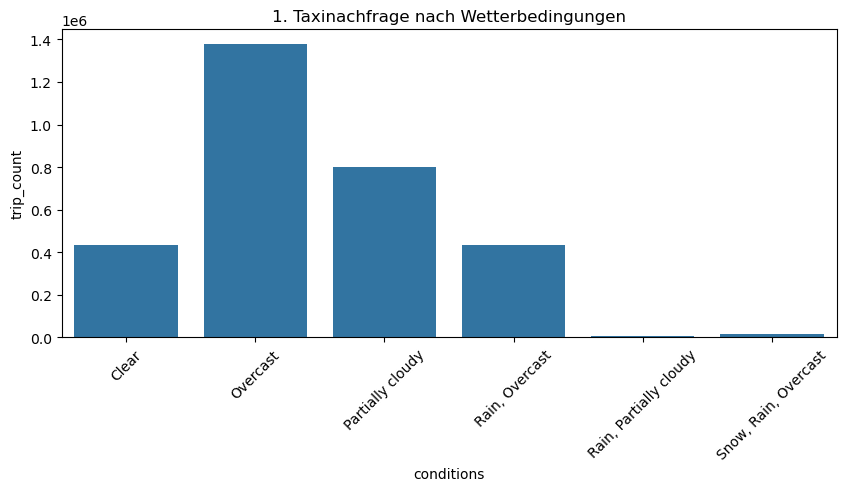

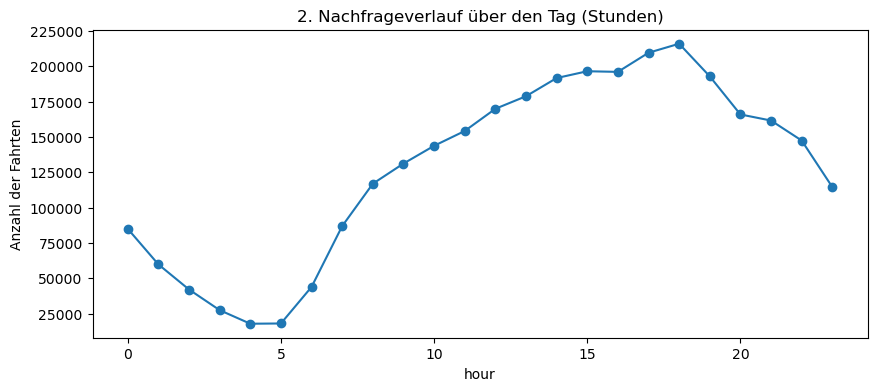

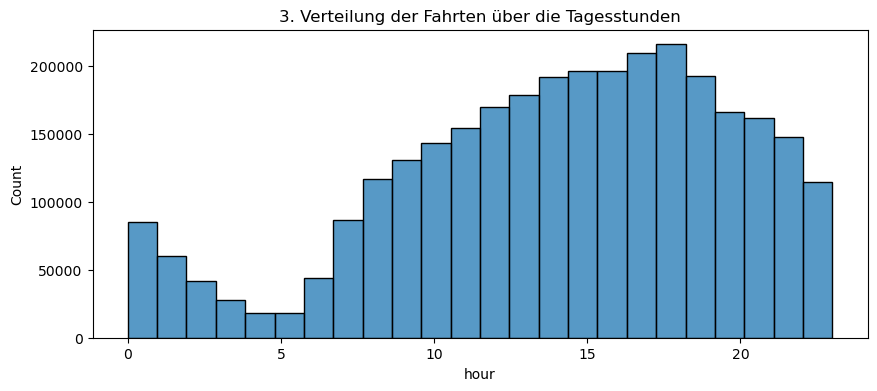

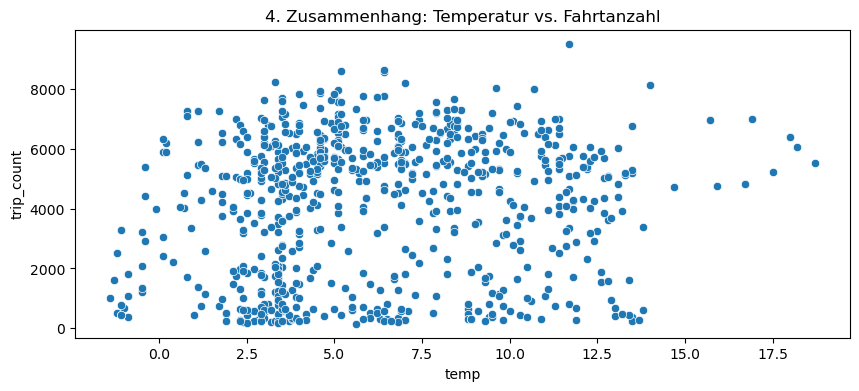

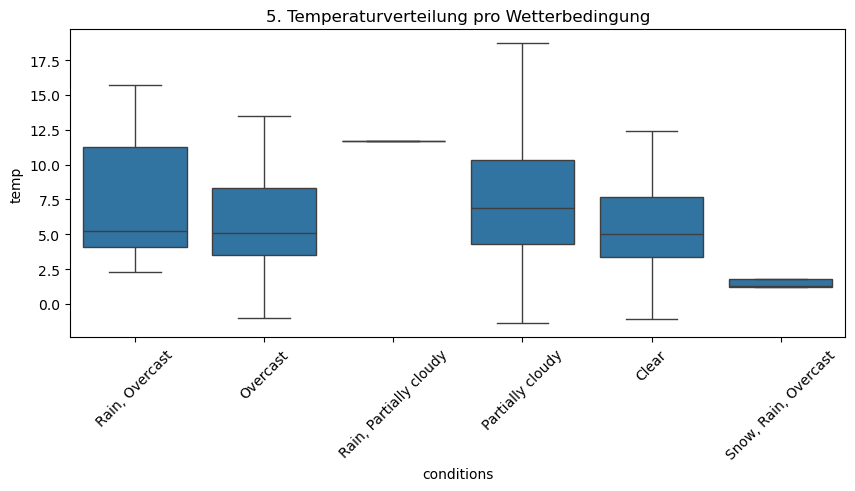

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vorbereitung: Aggregationen für die Visualisierungen
nach_wetter = analysis_df.groupby('conditions').size().reset_index(name='trip_count')
nach_stunde = analysis_df.groupby('hour').size()
nach_temperatur = analysis_df.groupby('date_hour').agg({'temp': 'mean', 'date_hour': 'size'}).rename(columns={'date_hour': 'trip_count'})

# 1. Balkendiagramm: Nachfrage nach Wetter
plt.figure(figsize=(10, 4))
sns.barplot(x='conditions', y='trip_count', data=nach_wetter)
plt.title('1. Taxinachfrage nach Wetterbedingungen')
plt.xticks(rotation=45)
plt.show()

# 2. Liniendiagramm: Nachfrage über den Tag
plt.figure(figsize=(10, 4))
nach_stunde.plot(kind='line', marker='o')
plt.title('2. Nachfrageverlauf über den Tag (Stunden)')
plt.ylabel('Anzahl der Fahrten')
plt.show()

# 3. Histogramm: Verteilung der Nachfrage nach Stunden
plt.figure(figsize=(10, 4))
sns.histplot(analysis_df['hour'], bins=24)
plt.title('3. Verteilung der Fahrten über die Tagesstunden')
plt.show()

# 4. Streudiagramm: Temperatur vs. Nachfrage
plt.figure(figsize=(10, 4))
sns.scatterplot(x='temp', y='trip_count', data=nach_temperatur)
plt.title('4. Zusammenhang: Temperatur vs. Fahrtanzahl')
plt.show()

# 5. Boxplot: Temperaturverteilung pro Wetterbedingung
plt.figure(figsize=(10, 4))
sns.boxplot(x='conditions', y='temp', data=analysis_df)
plt.xticks(rotation=45)
plt.title('5. Temperaturverteilung pro Wetterbedingung')
plt.show()

### 5.3 Interpretation der Visualisierungen 

Um die Auswirkungen der Wetterbedingungen auf die Taxinachfrage ganzheitlich zu verstehen, haben wir fünf verschiedene Visualisierungen erstellt. Diese dienen als Grundlage für unsere Datenstory:

**Interpretation der Ergebnisse:**

1. **Taxinachfrage nach Wetterbedingungen (Balkendiagramm):**
   Der Großteil der Fahrten findet bei 'Clear'-Bedingungen statt. Auffällig ist, dass bei Wetterereignissen wie 'Rain' oder 'Snow' die Nachfrage im Vergleich zu klarem Wetter sinkt. Dies deutet auf eine veränderte Mobilitätsplanung der Stadtbewohner hin, die bei widrigem Wetter eher auf den öffentlichen Nahverkehr ausweichen oder ihre Fahrten einschränken.

2. **Nachfrageverlauf über den Tag (Liniendiagramm):**
   Die Kurve bildet typische Spitzenwerte (Peaks) ab, die stark mit den morgendlichen und abendlichen Pendlerströmen korrelieren. Diese Visualisierung verdeutlicht, dass die Nachfrage nicht konstant ist, sondern eine hohe Zeitabhängigkeit aufweist.

3. **Verteilung der Fahrten über die Tagesstunden (Histogramm):**
   Die Häufigkeitsverteilung zeigt eine starke Konzentration der Fahrten in den Stoßzeiten. Diese Erkenntnis ist für Taxiunternehmen zentral, um die Flottensteuerung und Ressourcenallokation (Bereitstellung von Taxis) bedarfsgerecht zu planen.

4. **Zusammenhang: Temperatur vs. Fahrtanzahl (Streudiagramm):**
   Dieses Diagramm verdeutlicht die Korrelation zwischen der Außentemperatur und der Buchungsanzahl. Ein Rückgang der Fahrten bei extremen Temperaturen (sehr kalt oder sehr heiß) wäre ein starkes Indiz für die Sensibilität der Nachfrage gegenüber klimatischen Extremen.

5. **Temperaturverteilung pro Wetterbedingung (Boxplot):**
   Die Boxplots zeigen die Temperaturspanne für jede Wetterkategorie. Dies dient zur Validierung der Datenqualität: Wir sehen, dass spezifische Wetterereignisse wie 'Snow' erwartungsgemäß bei niedrigeren Temperaturen auftreten, während 'Clear' oder 'Rain' in breiteren Temperaturbereichen vorkommen.ereichen vorkommen.

### 6. Fazit und datengetriebene Erkenntnisse

Dieses Projekt hat die Anwendung von Big-Data-Technologien auf reale Mobilitäts- und Wetterdaten demonstriert. Über die rein technische Umsetzung hinaus haben die Analysen klare Zusammenhänge zwischen Umweltfaktoren und dem städtischen Verkehrsaufkommen offengelegt:

**Wichtigste Erkenntnisse aus den Daten:**

* **Wetter-Sensitivität:** Die Daten zeigen deutlich, dass die Taxinachfrage nicht isoliert betrachtet werden kann. Bei widrigen Bedingungen wie 'Rain' oder 'Snow' sinkt das Fahrtaufkommen signifikant. Dies deutet darauf hin, dass die Bewohner von New York ihre Mobilitätsentscheidungen aktiv an die Wetterlage anpassen (z. B. durch Ausweichen auf die U-Bahn).
* **Zeitliche Abhängigkeit:** Die ausgeprägten Spitzen im Tagesverlauf (Peaks) bestätigen, dass die Taxinachfrage in New York stark durch den Berufsverkehr geprägt ist. Die Daten lassen darauf schließen, dass die operative Auslastung der Flotte fast ausschließlich durch den Pendler-Rhythmus bestimmt wird.
* **Klimatischer Einfluss:** Obwohl die Temperatur einen gewissen Einfluss hat, zeigt sich, dass die *Art* des Wetters (Bedingungen wie Regen) einen stärkeren Effekt auf die Nachfrage hat als die reine Temperatur.

**Abschließendes Urteil:**

Die Analyse unterstreicht das Potenzial von datengestützten Entscheidungen für die Stadtplanung und Logistik. Ein Unternehmen, das diese Korrelationen zwischen Wetter und Nachfrage in Echtzeit in sein Buchungssystem integriert, könnte die Flottenverfügbarkeit dynamisch anpassen und so die Effizienz massiv steigern.